<a href="https://colab.research.google.com/github/kayurh/data_analytics/blob/main/5_1_lecture_Kayur_Amour_Harry.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Lesson 5 – Scaling and Normalization 1.

- In previous lessons, we examined the distributions of data, outliers, and the relationships between variables.  
- However, these analyses often compare variables with different measurement units and different ranges.

### In today’s lesson

- In this notebook, we examine what the “magnitude” and “deviation” of data mean, and when it becomes problematic to handle variables with different scales together.  
- Scaling and normalization are not mandatory technical steps, but interpretation decisions.  
- If we do not apply them, we still make implicit assumptions about which variables matter more in the analysis.  
- In this notebook, the main goal is not the application of specific methods, but understanding when and why scaling becomes necessary.

## California Housing dataset

The California Housing dataset is a classic regression dataset that contains statistical characteristics of residential properties located in different districts of California.

The data originate from the 1990 U.S. census, and each row represents a geographic district. The columns describe demographic and housing market characteristics, such as the median value of houses, the number of rooms, or  
population density.


**Dataset variables**

Each row of the dataset represents a district in California.  
The main variables are:

- **MedInc** – median household income in the district  
- **HouseAge** – median age of houses (in years)  
- **AveRooms** – average number of rooms per dwelling  
- **AveBedrms** – average number of bedrooms per dwelling  
- **Population** – total population of the district  
- **AveOccup** – average number of residents per dwelling  
- **Latitude** – geographic latitude of the district  
- **Longitude** – geographic longitude of the district  


**Target variable**

- **MedHouseVal** – median value of houses in the district  
  (measured in units of 100,000 USD)

This means that if the value is **2.5**, then  
the median house price is approximately **250,000 USD**.

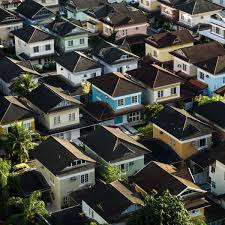

In [ ]:
from sklearn.datasets import fetch_california_housing
import pandas as pd
import numpy as np

# Load the California Housing dataset
housing = fetch_california_housing(as_frame=True)
df = housing.frame.copy()

df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [ ]:
df.describe().T[["min", "max", "mean"]]

,min,max,mean
MedInc,0.499900,15.000100,3.870671
HouseAge,1.000000,52.000000,28.639486
AveRooms,0.846154,141.909091,5.429000
AveBedrms,0.333333,34.066667,1.096675
Population,3.000000,35682.000000,1425.476744
AveOccup,0.692308,1243.333333,3.070655
Latitude,32.540000,41.950000,35.631861
Longitude,-124.350000,-114.310000,-119.569704
MedHouseVal,0.149990,5.000010,2.068558


## Comparing variables with different scales using a boxplot

Let us examine the distributions of some numerical variables at the same time.  
A boxplot helps us understand distributions and outliers, but here it also highlights another question:  

- what happens if we plot variables with very different ranges together?


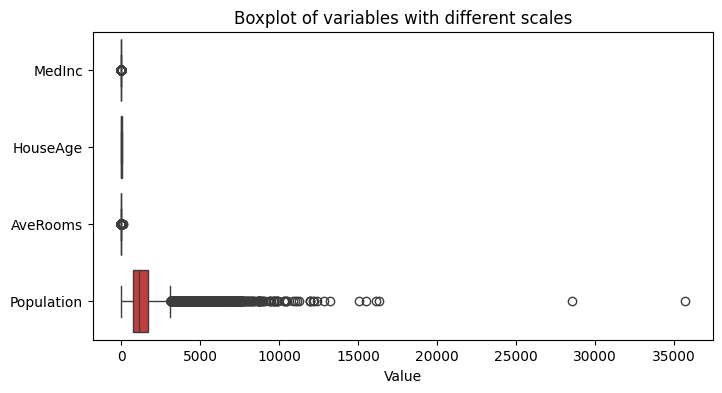

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Select a few interpretable numerical variables
cols = ["MedInc", "HouseAge", "AveRooms", "Population"]

# Create a figure with a specified size
plt.figure(figsize=(8, 4))

# Plot the boxplot of the selected variables in a horizontal layout
sns.boxplot(data=df[cols], orient="h")

# Add title and axis label
plt.title("Boxplot of variables with different scales")
plt.xlabel("Value")

# Display the plot
plt.show()

**Question:**

- Which variable can we actually infer anything about from this figure?  
- Is this figure “bad”, or is the joint visualization of the data the problem?

## Boxplot with a logarithmic axis

One possible solution to the problem of different scales is the use of a logarithmic axis.  
Let us examine how the interpretability of the figure changes if we set the x-axis to a log scale.


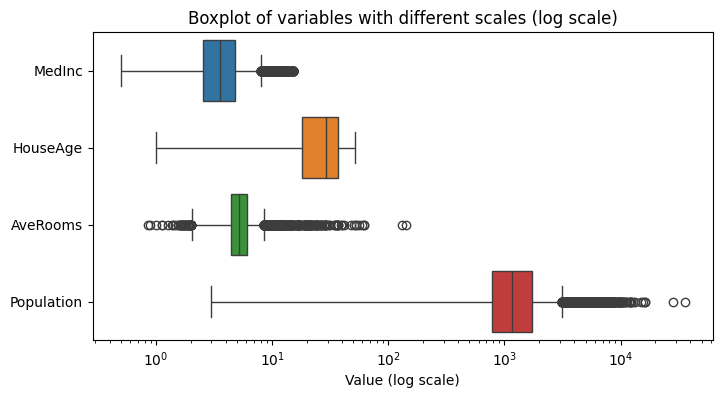

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Previously selected numerical variables with different scales
cols = ["MedInc", "HouseAge", "AveRooms", "Population"]

# Create a figure with a specified size
plt.figure(figsize=(8, 4))

# Plot the boxplot of the selected variables in a horizontal layout
sns.boxplot(data=df[cols], orient="h")

# Set the horizontal axis to a logarithmic scale
plt.xscale("log")

# Add title and axis label
plt.title("Boxplot of variables with different scales (log scale)")
plt.xlabel("Value (log scale)")

# Display the plot
plt.show()

**Observation:**

- A logarithmic scale helps variables with different orders of magnitude appear in a single figure,  
- but the interpretation is still difficult, and the meaning of the original measurement units is partly lost.

This is not scaling, but a visualization trick. (“Log scale ≠ scaling”)

## The same difference on an absolute and logarithmic scale

Let us examine two houses along two different characteristics:

- floor area (m²)  
- purchase price (USD)

First, we calculate the differences in **absolute terms**  
(using simple subtraction), then we compare them on a **logarithmic scale**.

The absolute difference shows  
by how much one value is larger than the other.

The logarithmic difference, in contrast, expresses more  
**how much the value has changed proportionally**.


In [ ]:
# Create a simple example DataFrame with two houses
df_exmpl = pd.DataFrame({
    "House": ["A", "B"],              # Identifier of the houses
    "Area_m2": [50, 60],              # Floor area of the houses in square meters
    "Price_USD": [200_000, 240_000]   # Price of the houses in US dollars
})

# Display the created example DataFrame
df_exmpl


,House,Area_m2,Price_USD
0,A,50,200000
1,B,60,240000


In [ ]:
# Absolute (arithmetic) differences
abs_diff = pd.Series({
    "Area difference (m2)": df_exmpl.loc[1, "Area_m2"] - df_exmpl.loc[0, "Area_m2"],
    "Price difference (USD)": df_exmpl.loc[1, "Price_USD"] - df_exmpl.loc[0, "Price_USD"]
})

abs_diff

,0
Area difference (m2),10
Price difference (USD),40000


In [ ]:
# Logarithmic differences
log_diff = pd.Series({
    "Area difference (log)": np.log(df_exmpl.loc[1, "Area_m2"]) - np.log(df_exmpl.loc[0, "Area_m2"]),
    "Price difference (log)": np.log(df_exmpl.loc[1, "Price_USD"]) - np.log(df_exmpl.loc[0, "Price_USD"])
})

log_diff


,0
Area difference (log),0.182322
Price difference (log),0.182322


In [ ]:
# Calculate the percentage change between the two houses
pct_diff = pd.Series({
    "Area change (%)": (
        (df_exmpl.loc[1, "Area_m2"] - df_exmpl.loc[0, "Area_m2"])
        / df_exmpl.loc[0, "Area_m2"]
    ) * 100,

    "Price change (%)": (
        (df_exmpl.loc[1, "Price_USD"] - df_exmpl.loc[0, "Price_USD"])
        / df_exmpl.loc[0, "Price_USD"]
    ) * 100
})

pct_diff

,0
Area change (%),20.0
Price change (%),20.0


**Observation:**

- In the case of absolute differences, the price difference is orders of magnitude larger than the difference in floor area.
- In the case of logarithmic differences, the two changes become similar in magnitude,
  because the logarithm emphasizes **proportional (relative) change**.
- Thus, the same two houses may appear “closer” or “farther apart”
  depending on whether we use **absolute or logarithmic differences**.

For this reason, scaling and transforming variables is not merely a technical
detail, but an **interpretation decision** that influences
how we perceive differences in the data.

### Why does scaling become important?

- In the previous examples, we saw that handling variables with different scales together can lead to interpretation problems.
- This is not an error in the methods, but a consequence of variables being measured in different units and ranges.
- Without scaling, the analysis implicitly decides which variables matter more – simply based o


## Min–max scale (0 - 1)

### What does it do?

- It places the data into a fixed range (between 0 and 1).
- The smallest value becomes 0, the largest becomes 1.

### When is it useful?

- When the relative magnitude of values is important.
- When natural lower and upper bounds matter.
- In visualizations and for comparability.

### When is it not useful?

- When there are many outliers: a single outlier can “compress” the data.

In [ ]:
# Min–Max scaling applied to a single column
def minmax_scale_apply(col):
    # Apply the Min–Max formula
    return (col - col.min()) / (col.max() - col.min())

# Selected variables
cols = ["MedInc", "HouseAge", "AveRooms", "Population"]
df_subset = df[cols].copy()

# Apply the function to each column
X_minmax_apply = df_subset.apply(lambda col: minmax_scale_apply(col), axis=0)

# Display the first rows
X_minmax_apply.head()

,MedInc,HouseAge,AveRooms,Population
0,0.539668,0.784314,0.043512,0.008941
1,0.538027,0.392157,0.038224,0.067210
2,0.466028,1.000000,0.052756,0.013818
3,0.354699,1.000000,0.035241,0.015555
4,0.230776,1.000000,0.038534,0.015752


The same solution using the built-in scikit-learn transformer, which can be trained and saved in a pipeline.

In [ ]:
from sklearn.preprocessing import MinMaxScaler

cols = ["MedInc", "HouseAge", "AveRooms", "Population"]
X = df[cols].copy()

scaler = MinMaxScaler()
X_minmax = pd.DataFrame(
                        scaler.fit_transform(X),
                        columns=cols,
                        index=df.index
                    )

X_minmax.head()


,MedInc,HouseAge,AveRooms,Population
0,0.539668,0.784314,0.043512,0.008941
1,0.538027,0.392157,0.038224,0.067210
2,0.466028,1.000000,0.052756,0.013818
3,0.354699,1.000000,0.035241,0.015555
4,0.230776,1.000000,0.038534,0.015752


Create a reusable function that allows us to visualize the distribution of the data.

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

## help function
def plot_scaled_data(df, X, label='', feature = "MedInc"):

  # Jitter for the y axis
  jitter = np.random.normal(0, 0.02, size=len(df))

  # 2x2 figure
  fig, axes = plt.subplots(2, 2, figsize=(10, 6))

  target = ['original', label]

  # Original and scaled jitter scatter
  for i,dat in enumerate([df,X]):
    axes[0, i].scatter(dat[feature], jitter, alpha=0.4)
    axes[0, i].set_title(f"{feature} ({target[i]})")
    axes[0, i].set_xlabel(feature)


  # Original and scaled histogram
  for i,dat in enumerate([df,X]):
    axes[1, i].hist(dat[feature], bins=30)
    axes[1, i].set_title(f"{feature} ({target[i]})")
    axes[1, i].set_xlabel(feature)

  plt.tight_layout()
  plt.show()
  return

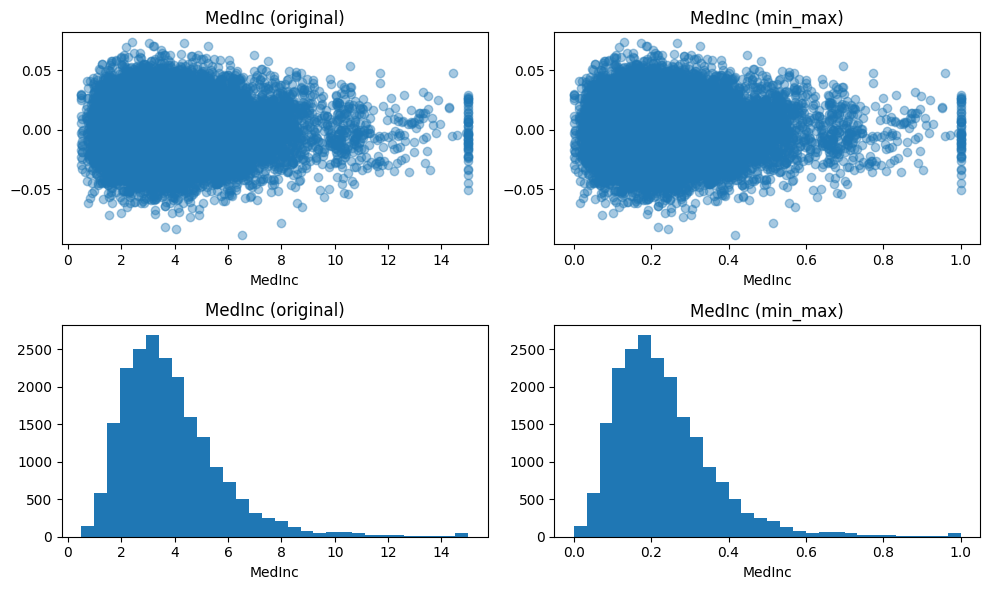

In [ ]:
# Plot the result of Min–Max scaling and the original data on a common figure
plot_scaled_data(df, X_minmax, label='min_max', feature="MedInc")

### Robust scaling (based on median and IQR)

What does it do?

- It considers the median as the center.
- Deviations are measured relative to the interquartile range.

When is it useful?

- When the data are noisy.
- When there are many outliers.
- When the “typical behavior” is more important than extreme cases.

When is it not useful?

- When the tails of the distribution are specifically of interest.
- When the data are already well-behaved.

In [ ]:
# Robust scaling applied to a single column
def robust_scale_apply(col):
    median = col.median()
    q1 = col.quantile(0.25)
    q3 = col.quantile(0.75)
    iqr = q3 - q1

    # RobustScaler formula
    return (col - median) / iqr

# Selected variables
cols = ["MedInc", "HouseAge", "AveRooms", "Population"]
df_subset = df[cols].copy()

# Apply the function to each column
X_rob_apply = df_subset.apply(lambda col: robust_scale_apply(col))

# Display the first rows
X_rob_apply.head()

,MedInc,HouseAge,AveRooms,Population
0,2.197582,0.631579,1.088935,-0.899787
1,2.186664,-0.421053,0.626066,1.316631
2,1.707732,1.210526,1.898042,-0.714286
3,0.967177,1.210526,0.364978,-0.648188
4,0.142854,1.210526,0.653191,-0.640725


The same solution using the built-in scikit-learn transformer, which can be trained and saved in a pipeline.

In [ ]:
from sklearn.preprocessing import RobustScaler

scaler = RobustScaler()  # default: center=median, scale=IQR
X_rob = pd.DataFrame(
                    scaler.fit_transform(X),
                    columns=cols,
                    index=df.index
                )

X_rob.head()


,MedInc,HouseAge,AveRooms,Population
0,2.197582,0.631579,1.088935,-0.899787
1,2.186664,-0.421053,0.626066,1.316631
2,1.707732,1.210526,1.898042,-0.714286
3,0.967177,1.210526,0.364978,-0.648188
4,0.142854,1.210526,0.653191,-0.640725


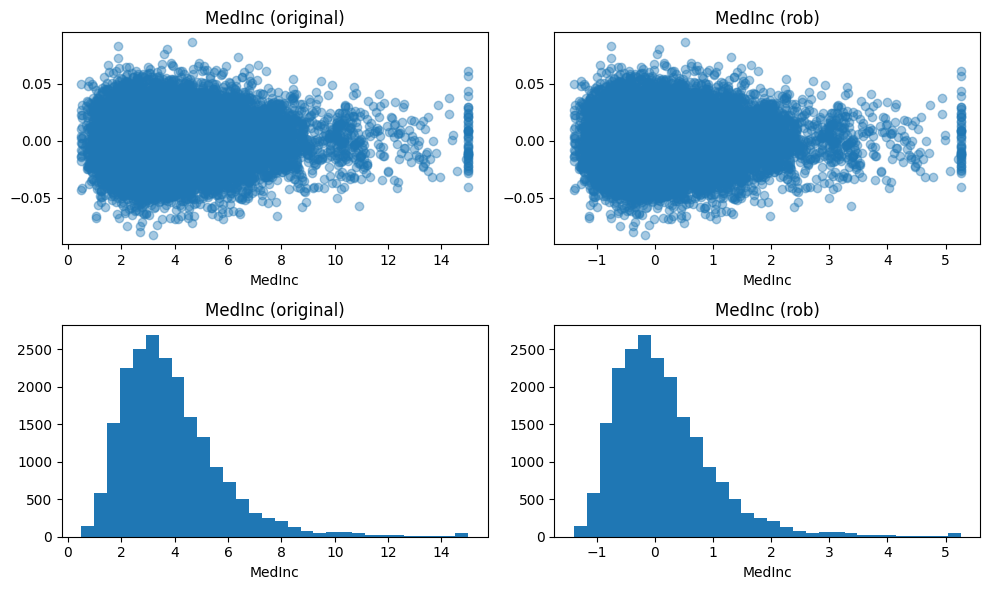

In [ ]:
# Plot the result of RobustScaler and the original data on a common figure
plot_scaled_data(df, X_rob, label='rob', feature = "MedInc")

### Standardization (z-score: mean 0, standard deviation 1)

During standardization, the variable is transformed so that
- its mean becomes 0
- its standard deviation becomes 1

When is it useful?

- When the “deviation from the mean” is important.
- When the shape of the distribution matters.
- When we want variables to be comparable regardless of units.

When is it not useful?

- When the distribution is highly skewed or contains many outliers, because the mean and standard deviation are not stable.

In [ ]:
# Standardization applied to a single column
def standard_scale_apply(col):
    mean = col.mean()
    std = col.std()

    # StandardScaler formula
    return (col - mean) / std

# Selected variables
cols = ["MedInc", "HouseAge", "AveRooms", "Population"]
df_subset = df[cols].copy()

# Apply the function to each column
X_std_apply = df_subset.apply(lambda col: standard_scale_apply(col))

# Display the first rows
X_std_apply.head()

,MedInc,HouseAge,AveRooms,Population
0,2.344709,0.982119,0.628544,-0.974405
1,2.332181,-0.607004,0.327033,0.861418
2,1.782656,1.856137,1.155592,-0.820757
3,0.932945,1.856137,0.156962,-0.766010
4,-0.012881,1.856137,0.344702,-0.759828


The same solution using the built-in scikit-learn transformer, which can be trained and saved in a pipeline.

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_std = pd.DataFrame(
                        scaler.fit_transform(X),
                        columns=cols,
                        index=df.index
                    )

X_std.head()


,MedInc,HouseAge,AveRooms,Population
0,2.344766,0.982143,0.628559,-0.974429
1,2.332238,-0.607019,0.327041,0.861439
2,1.782699,1.856182,1.155620,-0.820777
3,0.932968,1.856182,0.156966,-0.766028
4,-0.012881,1.856182,0.344711,-0.759847


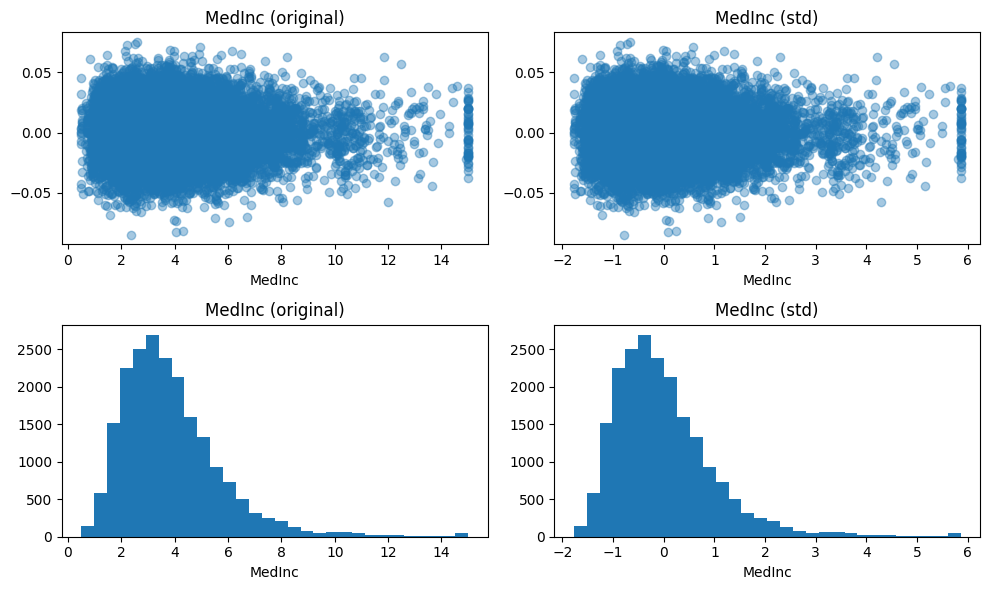

In [ ]:
# Plot the result of StandardScaler and the original data on a common figure
plot_scaled_data(df, X_std, label='std', feature = "MedInc")

## Effect of scaling and standardization on distributions – comparison with boxplots

In the following figure, we plot the same variables in four different forms:

- original data  
- min–max scaling  
- standardization  
- robust scaling  

The goal is not to decide which one is “better”, but to observe how the interpretability of the distributions changes as a result of scaling.

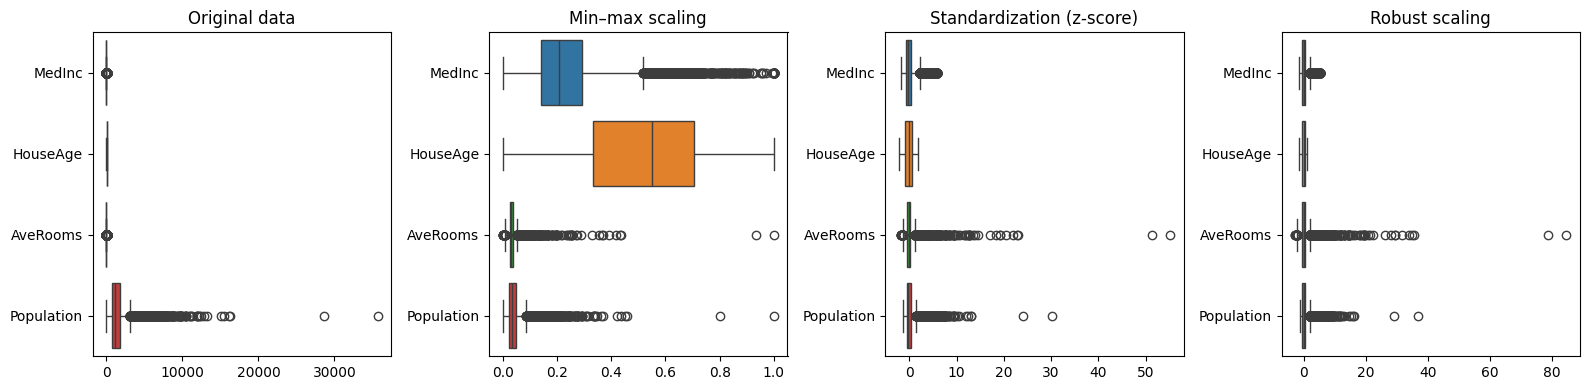

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

cols = ["MedInc", "HouseAge", "AveRooms", "Population"]

fig, axes = plt.subplots(1, 4, figsize=(16, 4), sharey=False)

# 1. Original data
sns.boxplot(data=df[cols], orient="h", ax=axes[0])
axes[0].set_title("Original data")

# 2. Min–max scaling
sns.boxplot(data=X_minmax[cols], orient="h", ax=axes[1])
axes[1].set_title("Min–max scaling")

# 3. Standardization
sns.boxplot(data=X_std[cols], orient="h", ax=axes[2])
axes[2].set_title("Standardization (z-score)")

# 4. Robust scaling
sns.boxplot(data=X_rob[cols], orient="h", ax=axes[3])
axes[3].set_title("Robust scaling")

plt.tight_layout()
plt.show()


## Handling outliers using the IQR method

Now we identify outliers using the IQR (interquartile range),
and instead of removing them, we clip them to the boundary values.

After that, we examine the distributions again and compare them with the previous results.

In [ ]:
# Define an IQR-based clipping function
def clip_iqr(series, factor=1.5):
    # Determine the lower and upper quartiles
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)

    # Compute the interquartile range
    iqr = q3 - q1

    # Determine the lower and upper bounds
    lower = q1 - factor * iqr
    upper = q3 + factor * iqr

    # Clip values outside the bounds
    return series.clip(lower, upper)

# Create a copy of the original DataFrame
df_iqr = df.copy()

# Apply IQR clipping to the selected variables
for col in cols:
    df_iqr[col] = clip_iqr(df_iqr[col])


In [ ]:
# Recomputing scaling on the IQR-treated data
from sklearn.preprocessing import MinMaxScaler, StandardScaler, RobustScaler

X_iqr = df_iqr[cols]

X_minmax_iqr = pd.DataFrame(
    MinMaxScaler().fit_transform(X_iqr),
    columns=cols,
    index=df_iqr.index
)

X_std_iqr = pd.DataFrame(
    StandardScaler().fit_transform(X_iqr),
    columns=cols,
    index=df_iqr.index
)

X_rob_iqr = pd.DataFrame(
    RobustScaler().fit_transform(X_iqr),
    columns=cols,
    index=df_iqr.index
)


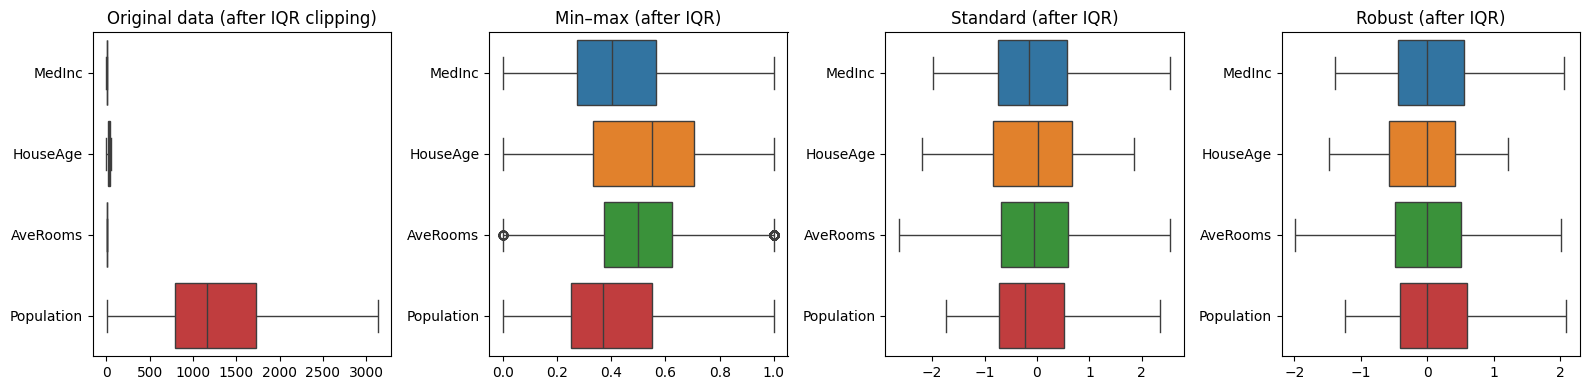

In [ ]:
# Boxplots again – after IQR-treated data
fig, axes = plt.subplots(1, 4, figsize=(16, 4), sharey=False)

sns.boxplot(data=df_iqr[cols], orient="h", ax=axes[0])
axes[0].set_title("Original data (after IQR clipping)")

sns.boxplot(data=X_minmax_iqr, orient="h", ax=axes[1])
axes[1].set_title("Min–max (after IQR)")

sns.boxplot(data=X_std_iqr, orient="h", ax=axes[2])
axes[2].set_title("Standard (after IQR)")

sns.boxplot(data=X_rob_iqr, orient="h", ax=axes[3])
axes[3].set_title("Robust (after IQR)")

plt.tight_layout()
plt.show()


## What do we learn from this figure?

- After scaling, the distributions of the variables become comparable.  
- While on the original scale variables with large ranges hide the others, in the scaled data the internal structure of each variable becomes visible (median, spread, width of the distribution).

Different scaling methods highlight different properties:
- min–max emphasizes the relative position,  
- standardization emphasizes deviation from the mean,  
- robust scaling emphasizes behavior around typical values.

Scaling does not add new information to the data, but makes visible what would remain hidden without scaling.

### Exercises

## Introduction to the Penguins dataset

The Penguins dataset contains morphometric data (body size and body structure measurements) of penguin speciesliving in the Antarctic region.  
The data refer to individual animals, and each row describes one penguin.

The goal of the dataset is not prediction, but the examination of differences and similarities between individuals, therefore it is especially suitable for analyzing distributions, scales, and groups.

### Main columns

- **species** – the species of the penguin (Adelie, Chinstrap, Gentoo)  
- **island** – the island where the individual was observed  
- **bill_length_mm** – bill length in millimeters  
- **bill_depth_mm** – bill depth in millimeters  
- **flipper_length_mm** – flipper length in millimeters  
- **body_mass_g** – body mass in grams  
- **sex** – the sex of the individual  

The dataset contains missing values, which naturally occur during field measurements. This also provides an opportunity to practice data cleaning  
and interpretation steps.

In this notebook, we use the Penguins dataset to examine the effect of scaling and grouping.


In [ ]:
import seaborn as sns
import pandas as pd

# Load the Penguins dataset
df = sns.load_dataset("penguins")

df.head()


,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female


In [ ]:
df.describe()

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
count,342.000000,342.000000,342.000000,342.000000
mean,43.921930,17.151170,200.915205,4201.754386
std,5.459584,1.974793,14.061714,801.954536
min,32.100000,13.100000,172.000000,2700.000000
25%,39.225000,15.600000,190.000000,3550.000000
50%,44.450000,17.300000,197.000000,4050.000000
75%,48.500000,18.700000,213.000000,4750.000000
max,59.600000,21.500000,231.000000,6300.000000


## Exercise 1 – Detecting outliers using the Z-score

The Z-score shows how many standard deviations a data point is away from the mean.

1. Select the `body_mass_g` variable from the penguins dataset.
2. Compute the Z-score values.
3. Find the data points where |Z| > 2.
4. How many such data points are there?
5. What do you think: are these true outliers, or could they rather be measurement errors?

**Question for reflection:**  
Why can it be problematic if there are many outliers in the data before scaling?

In [1]:
import seaborn as sns
import pandas as pd
import numpy as np

df = sns.load_dataset("penguins")

x = df["body_mass_g"].dropna()
z = (x - x.mean()) / x.std()

outliers = x[abs(z) > 2]
print(len(outliers))

9


## Exercise 2 – Outlier filtering based on IQR

In the previous lesson, we used the IQR method to identify outliers.

1. Select the `flipper_length_mm` variable.
2. Compute the values of Q1, Q3, and IQR.
3. Determine the bounds:

   lower bound = Q1 − 1.5 × IQR  
   upper bound = Q3 + 1.5 × IQR

4. Filter out the data points falling outside these bounds.

**Question:**  
How many data points were removed by the IQR method?

**Question for reflection:**  
Why do you think this method can be more robust than the Z-score?

In [2]:
x = df["flipper_length_mm"].dropna()

Q1 = x.quantile(0.25)
Q3 = x.quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

filtered = x[(x >= lower) & (x <= upper)]
print(len(x) - len(filtered))

0


## Exercise 3 – Which scaling method is the best?

The penguins dataset may contain a few outliers.

1. Examine the distribution of the `body_mass_g` variable using a boxplot.
2. Apply separately:

- MinMaxScaler
- StandardScaler
- RobustScaler

3. Create a boxplot for all three scaled variables.

**Questions:**

- Which method handles outliers the best?
- Which method preserves the structure of the distribution the most?

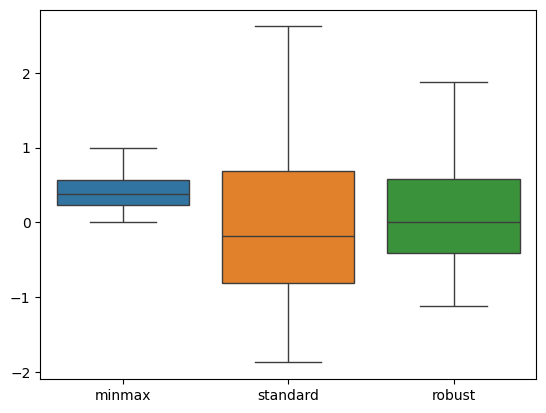

In [3]:
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler, StandardScaler, RobustScaler

x = df[["body_mass_g"]].dropna()

minmax = MinMaxScaler().fit_transform(x)
standard = StandardScaler().fit_transform(x)
robust = RobustScaler().fit_transform(x)

scaled = pd.DataFrame({
    "minmax": minmax.flatten(),
    "standard": standard.flatten(),
    "robust": robust.flatten()
})

sns.boxplot(data=scaled)
plt.show()